### 4.4 SVAR — structural systems for both CPI measures

$$y_t = c + A_1y_{t-1} + A_2y_{t-2} + u_t,\quad u_t\sim(0,\Sigma)$$

$$\Sigma = PP',\qquad \varepsilon_t = P^{-1}u_t$$

$$\Theta_h = \Phi_h P$$

Two five-variable VAR(2)-in-levels systems (System A → `cpi_yoy`, System B →
`trimmed_mean_cpi_yoy`), recursive Cholesky ordering commodity growth → unemployment →
CPI target → business inflation expectations → cash rate, 80% contiguous block-bootstrap
IRF bands. **Read every panel below as illustrative, not causal** — both systems still
reject multivariate residual whiteness and normality after COVID treatment checks.

*Source: `src/models/svar.py`, exported to `reports/tableau/svar_irf.csv`*

In [ ]:
import sys, warnings
from pathlib import Path

PROJECT_ROOT = Path.cwd()
for _ in range(4):
    if (PROJECT_ROOT / "reports").is_dir() and (PROJECT_ROOT / "data").is_dir():
        break
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

INK, PAPER, ACCENT, ACCENT_SOFT, HIGHLIGHT, GRID = (
    "#16211c", "#f7f8f5", "#1f6f66", "#bfe3dd", "#a8691f", "#d9ddd6",
)
BLUE, PLUM, MUTED, ALERT = "#5b6f8f", "#8a4f8a", "#9aa79f", "#c0392b"
plt.rcParams.update({
    "figure.facecolor": PAPER, "axes.facecolor": PAPER, "axes.edgecolor": GRID,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": INK, "ytick.color": INK,
    "font.size": 11, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
})

import matplotlib.dates as mdates

def year_axis(ax, step=5):
    ax.xaxis.set_major_locator(mdates.YearLocator(step))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

CURATED = PROJECT_ROOT / "data" / "curated" / "quarterly_macro_features.csv"
TABLEAU = PROJECT_ROOT / "reports" / "tableau"

import matplotlib.animation as animation
from IPython.display import Image, display

**Why levels, not differences.** Both systems are estimated in levels rather than first
differences — a choice grounded in mixed unit-root evidence, not a clean stationarity
finding. Headline `cpi_yoy` is stationary at level (ADF p=0.0299, KPSS p=0.10), but
`trimmed_mean_cpi_yoy` is not (level ADF p=0.1896 fails to reject a unit root, while
KPSS p=0.10 does not reject stationarity either) — it only passes both tests after
first-differencing (ADF p=0.0000, KPSS p=0.10). Running both systems on levels keeps
System A and System B directly comparable and preserves each series' long-run
relationships with the other four macro variables, at the cost of carrying System B's
undifferenced, borderline-unit-root behaviour into every IRF and historical-decomposition
panel below.

*Source: [Appendix §5 — Stationarity Tests](../appendix_eda/05_stationarity_tests), [Appendix §15 — Documented Limitations](../appendix_eda/15_documented_limitations)*

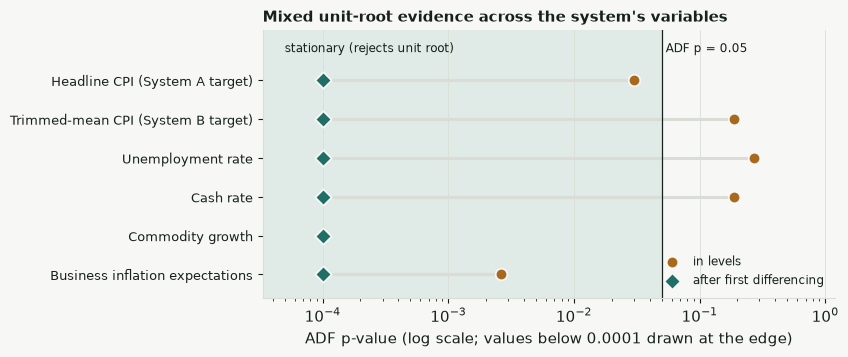

In [2]:
from statsmodels.tsa.stattools import adfuller
from src.models import svar

df = pd.read_csv(CURATED)
df = df[df["quarter"] <= str(svar.FORECAST_ORIGIN_PIN)]
variables = [
    ("cpi_yoy", "Headline CPI (System A target)"),
    ("trimmed_mean_cpi_yoy", "Trimmed-mean CPI (System B target)"),
    ("unemployment_rate", "Unemployment rate"),
    ("cash_rate", "Cash rate"),
    ("commodity_growth", "Commodity growth"),
    ("inflation_expectations_business", "Business inflation expectations"),
]
rows = []
for col, label in variables:
    s = df[col].dropna()
    rows.append((label, adfuller(s, autolag="AIC")[1], adfuller(s.diff().dropna(), autolag="AIC")[1]))
res = pd.DataFrame(rows, columns=["label", "level", "diff1"]).iloc[::-1].reset_index(drop=True)
floor = 1e-4                                            # p-values below this are drawn at the floor

fig, ax = plt.subplots(figsize=(8.6, 3.7))
ax.axvspan(floor / 3, 0.05, color=ACCENT, alpha=0.10, linewidth=0)
ax.axvline(0.05, color=INK, linewidth=0.9)
for y, r in res.iterrows():
    lo, hi = sorted([max(r["level"], floor), max(r["diff1"], floor)])
    ax.plot([lo, hi], [y, y], color=GRID, linewidth=2.2, zorder=1)
ax.scatter(res["level"].clip(lower=floor), res.index, s=70, color=HIGHLIGHT, edgecolor=PAPER, linewidth=1.3,
           zorder=3, label="in levels")
ax.scatter(res["diff1"].clip(lower=floor), res.index, s=70, marker="D", color=ACCENT, edgecolor=PAPER,
           linewidth=1.3, zorder=3, label="after first differencing")
ax.set_xscale("log")
ax.set_xlim(floor / 3, 1.2)
ax.set_yticks(res.index, res["label"], fontsize=9)
ax.text(0.05, len(res) - 0.35, " ADF p = 0.05", fontsize=8.5, va="bottom")
ax.text(floor / 2, len(res) - 0.35, "stationary (rejects unit root)", fontsize=8.5, va="bottom")
ax.set_ylim(-0.6, len(res) + 0.3)
ax.set_xlabel("ADF p-value (log scale; values below 0.0001 drawn at the edge)")
ax.set_title("Mixed unit-root evidence across the system's variables",
             loc="left", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

#### Explained, step by step

- $y_t$ is a **vector** of five variables at once (commodity-price growth, unemployment, the CPI target, business inflation expectations, the cash rate) — not a single series like SARIMA. $A_1, A_2$ are $5\times5$ matrices saying how *all five* variables at $t-1$ and $t-2$ feed into *all five* variables at $t$; $c$ is a constant/intercept vector.
- $u_t$ is the vector of **reduced-form residuals** — the part of this quarter's movement the lagged history couldn't explain. $\Sigma$ is their covariance matrix: it captures that these five residuals are correlated *within* the same quarter (e.g. a bad quarter for commodity prices and a bad quarter for unemployment often coincide) — but a plain VAR can't say which one "caused" the other within that same quarter.
- $\Sigma = PP'$ is a **Cholesky decomposition**: splitting the correlated covariance matrix into a lower-triangular matrix $P$ such that $PP'$ reconstructs $\Sigma$. $\varepsilon_t = P^{-1}u_t$ then converts the correlated residuals $u_t$ into new shocks $\varepsilon_t$ that are, by construction, uncorrelated with each other — genuinely independent, "structural" shocks.
- The catch — why the app keeps warning "illustrative, not causal" — is that this decomposition requires imposing an **ordering**: here, commodity growth $\to$ unemployment $\to$ CPI target $\to$ business inflation expectations $\to$ cash rate. This encodes an assumption that a commodity-price shock can move unemployment *within the same quarter*, but a same-quarter cash-rate shock cannot instantaneously move commodity prices. That's a judgment call the data doesn't prove — a different, equally defensible ordering could shift the results. ([Appendix §12 — Rolling Correlations / Relationship Stability](../appendix_eda/12_rolling_correlations) shows these cross-series relationships aren't fixed over the sample either, which is exactly why a single static ordering is a simplification.)
- $\Theta_h = \Phi_h P$ is the **impulse response function (IRF)**: $\Phi_h$ (standard VAR theory) says how a shock to the *reduced-form* residuals propagates $h$ quarters forward; multiplying by $P$ converts that into "how does one unit of *structural* shock $\varepsilon$ (e.g. an independent unemployment surprise) move the CPI target $h$ quarters later, holding every other variable's same-quarter shock fixed." That's exactly what the IRF chart below plots.
- The historical decomposition below flips the IRF's question around: instead of "what would a hypothetical shock do," it asks "what did the shocks that actually happened do." It reuses the *same* $P$ and the *same* fitted VAR — it re-runs the model forward from its own initial conditions with every shock forced to zero (the *baseline*), then adds back each quarter's actual recovered structural shocks $\varepsilon_t$ one driver at a time. Because $u_t = P\varepsilon_t$ and the VAR is linear, baseline + all shock contributions reconstructs the actual path *exactly*, not approximately — it's bookkeeping on top of the same identified system, not a new model.
- **The structural shock is not the same as the plain forecast error.** The VAR's own single-equation residual $u_t$ (actual minus what *that one equation's* lags predicted) and the structural shock $\varepsilon_t$ (after the $P^{-1}$ rotation) can differ in both size and sign, because the ordering lets earlier variables' *same-quarter* shocks spill into later ones. A quarter can show a small structural shock even when the raw single-equation miss was larger, if most of that miss is attributable to a contemporaneous shock elsewhere in the system rather than to the target itself — see the worked example below.

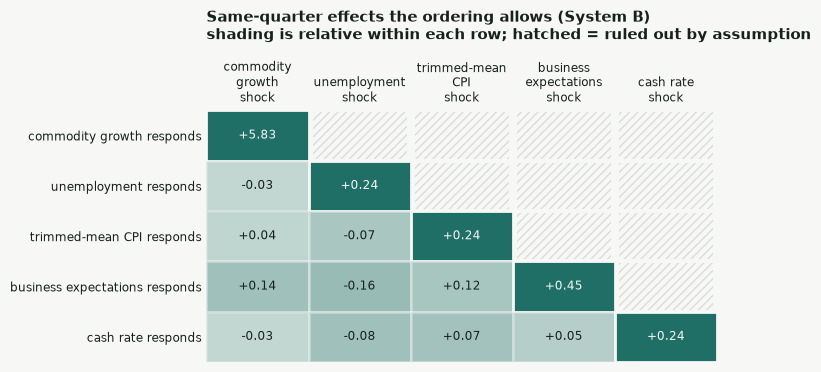

In [3]:
from src.models import svar
from src.models.tableau_export import SVAR_SYSTEMS

config = SVAR_SYSTEMS["System B"]
frame = svar.load_svar_level_frame(columns=config["columns"])
frame = frame.loc[frame.index <= svar.FORECAST_ORIGIN_PIN]
fitted = svar.fit_svar(frame, ordering=config["ordering"])
names = [str(n) for n in fitted.names]                      # the recursive Cholesky order
P = np.asarray(fitted.irf(periods=1).P, dtype=float)        # P[i, j]: impact of shock j on variable i, same quarter
pretty = {"trimmed_mean_cpi_yoy": "trimmed-mean\nCPI", "inflation_expectations_business": "business\nexpectations",
          "unemployment_rate": "unemployment", "cash_rate": "cash rate", "commodity_growth": "commodity\ngrowth"}
labels = [pretty.get(n, n) for n in names]

fig, ax = plt.subplots(figsize=(7.4, 4.0))
n = len(names)
for i in range(n):
    for j in range(n):
        blocked = j > i
        rel = abs(P[i, j]) / np.abs(P[i]).max()          # shade within a row: rows are in different units
        if blocked:
            ax.add_patch(plt.Rectangle((j - 0.46, i - 0.46), 0.92, 0.92, fill=False, hatch="////",
                                       edgecolor=GRID, linewidth=0))
            continue
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=ACCENT, alpha=0.12 + 0.88 * rel,
                                   edgecolor=PAPER, linewidth=2))
        ax.text(j, i, f"{P[i, j]:+.2f}", ha="center", va="center", fontsize=8.5,
                color=PAPER if rel > 0.6 else INK)
ax.set_xlim(-0.5, n - 0.5)
ax.set_ylim(n - 0.5, -0.5)
ax.set_xticks(range(n), [f"{l}\nshock" for l in labels.copy()], fontsize=8.5)
ax.xaxis.tick_top()
ax.set_yticks(range(n), [f"{l.replace(chr(10), ' ')} responds" for l in labels], fontsize=8.5)
ax.grid(False)
ax.tick_params(length=0)
for s in ax.spines.values():
    s.set_visible(False)
ax.set_title("Same-quarter effects the ordering allows (System B)\nshading is relative within each row; hatched = ruled out by assumption",
             loc="left", fontsize=10.5, fontweight="bold", y=1.25)
fig.tight_layout()
plt.show()

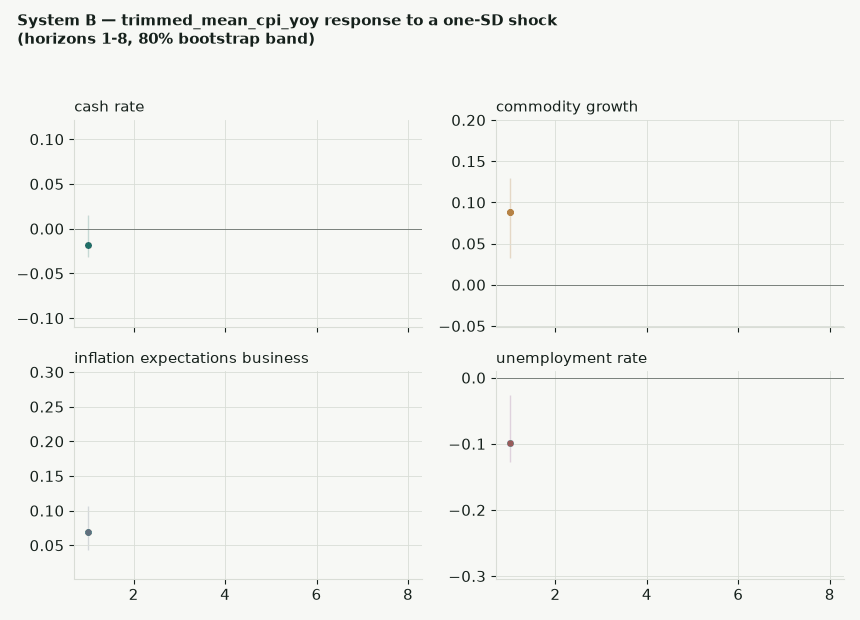

In [2]:
irf = pd.read_csv(PROJECT_ROOT / "reports/tableau/svar_irf.csv")
irf = irf[(irf["system"] == "System B") & (irf["response"] == "trimmed_mean_cpi_yoy")].copy()
shocks = sorted(irf["shock"].unique())
scolors = {shocks[0]: ACCENT, shocks[1]: HIGHLIGHT, shocks[2]: "#5b6f8f", shocks[3]: "#8a4f8a"}

fig, axes = plt.subplots(2, 2, figsize=(8.6, 6.2), sharex=True)
axes = axes.ravel()
lines, bands = [], []
for ax, shock in zip(axes, shocks):
    ax.axhline(0, color=INK, linewidth=0.7, alpha=0.5)
    ax.set_title(shock.replace("_", " "), fontsize=10.5, loc="left")
    ax.set_xlim(0.7, 8.3)
    sub = irf[irf["shock"] == shock].sort_values("horizon")
    pad = 0.15 * (sub["upper"].max() - sub["lower"].min())
    ax.set_ylim(sub["lower"].min() - pad, sub["upper"].max() + pad)
    bands.append(ax.fill_between([], [], [], color=scolors[shock], alpha=0.22))
    line, = ax.plot([], [], color=scolors[shock], linewidth=2.0, marker="o", markersize=4)
    lines.append(line)
fig.suptitle("System B — trimmed_mean_cpi_yoy response to a one-SD shock\n(horizons 1-8, 80% bootstrap band)",
             fontsize=10.8, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.95))

def update_irf(h):
    for i, shock in enumerate(shocks):
        sub = irf[irf["shock"] == shock].sort_values("horizon")
        sub = sub[sub["horizon"] <= h]
        lines[i].set_data(sub["horizon"], sub["irf"])
        bands[i].remove()
        bands[i] = axes[i].fill_between(sub["horizon"], sub["lower"], sub["upper"], color=scolors[shock], alpha=0.22)
    return lines

anim_irf = animation.FuncAnimation(fig, update_irf, frames=list(range(1, 9)) + [8] * 6, interval=350, blit=False)
gif_path = PROJECT_ROOT / "notebooks/assets/svar_animation.gif"
gif_path.parent.mkdir(parents=True, exist_ok=True)
anim_irf.save(gif_path, writer=animation.PillowWriter(fps=3))
plt.close(fig)
Image(filename=str(gif_path))

#### Shock events — where the model flags unusual moves

`structural_shocks()` recovers each system's independent shocks from its own reduced-form
residuals; `svar_shock_events.csv` z-scores each system's own-target shock against its own
history and flags whichever quarters cross `|z| > 2`. Two systems, one shared threshold,
13 flagged quarters total — the GST introduction and its 2000-2001 base-effect unwind and
the 2021 post-COVID inflation surge for headline; the GFC-era spike (2007-2009) and
underlying-inflation persistence through 2022-2023's hiking cycle for trimmed mean.

The most recent episode flagged in **both** systems is the 2021 post-COVID reflation —
trimmed mean flags 2021Q1, headline flags 2021Q2-3, one quarter apart. That's the episode
decomposed below. (2022Q4/2023Q4 are a separate, later, trimmed-mean-only episode — hiking-
cycle persistence, not covered here.)

*Source: `src/models/svar.py::structural_shocks`, exported to
`reports/tableau/svar_shock_events.csv`*

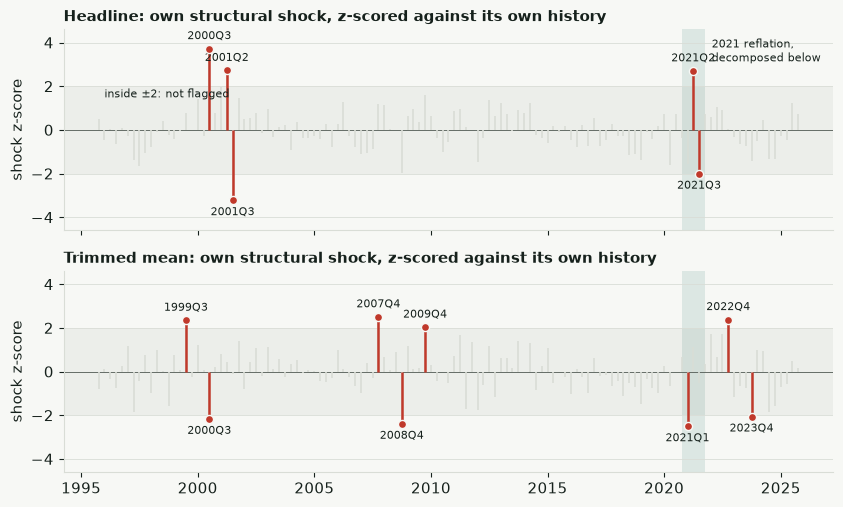

In [4]:
events = pd.read_csv(TABLEAU / "svar_shock_events.csv")
events["date"] = pd.PeriodIndex(events["quarter"], freq="Q").to_timestamp()
SHOCK_COLOR = "#c0392b"

fig, axes = plt.subplots(2, 1, figsize=(8.6, 5.2), sharex=True)
for ax, (system, label) in zip(axes, [("System A", "Headline"), ("System B", "Trimmed mean")]):
    sub = events[events["system"] == system].sort_values("date")
    flagged = sub[sub["flagged"]]
    ax.axhspan(-2, 2, color=GRID, alpha=0.35, linewidth=0)
    ax.axhline(0, color=INK, linewidth=0.7, alpha=0.6)
    ax.axvspan(pd.Timestamp("2020-10-01"), pd.Timestamp("2021-10-01"), color=ACCENT, alpha=0.12, linewidth=0)
    ax.vlines(sub["date"], 0, sub["shock_z"], color=GRID, linewidth=1.2, zorder=2)
    ax.vlines(flagged["date"], 0, flagged["shock_z"], color=SHOCK_COLOR, linewidth=1.8, zorder=3)
    ax.scatter(flagged["date"], flagged["shock_z"], s=34, color=SHOCK_COLOR, edgecolor=PAPER, linewidth=1.0, zorder=4)
    for k, (_, r) in enumerate(flagged.iterrows()):
        up = r["shock_z"] > 0
        ax.annotate(r["quarter"], (r["date"], r["shock_z"]), xytext=(0, 5 if up else -5), textcoords="offset points",
                    ha="center", va="bottom" if up else "top", fontsize=7.6)
    ax.set_ylim(-4.6, 4.6)
    ax.set_ylabel("shock z-score")
    ax.set_title(f"{label}: own structural shock, z-scored against its own history", loc="left",
                 fontsize=10.5, fontweight="bold")
    ax.grid(axis="x", visible=False)
axes[0].text(pd.Timestamp("2022-01-15"), 3.6, "2021 reflation,\ndecomposed below", ha="left", va="center", fontsize=8)
axes[0].text(pd.Timestamp("1996-01-01"), 1.9, "inside ±2: not flagged", fontsize=8, va="top")
year_axis(axes[1], 5)
fig.tight_layout()
plt.show()

#### What a shock looks like on the series itself

A shock is defined as *actual minus the model's own prediction*, so it's worth seeing that
gap directly on the two series, not just as an abstract z-score in the chart above.

The dashed line below is each series with its own structural shock $\varepsilon_t$
subtracted out, quarter by quarter. This isn't a genuine out-of-sample forecast — it
uses the same quarter's realizations of the other four structural shocks too, which a real
forecast wouldn't have in advance — it's a **shock-neutral counterfactual**: what this
quarter's value would have been if only the target's *own* idiosyncratic surprise were
removed. The shaded gap between the two lines is exactly that shock, and the same flagged
quarters from the chart above are marked in red.

**Read the closeness with one more caveat: this is a full-sample, in-sample decomposition, not a walk-forward forecast.** `fit_svar()` is called *once*, on all 30 years of data (1995Q4-2025Q4), and that single fit is reused to compute the "implied" value for every historical quarter shown below — including 1996. A real 1996 forecaster never had the three decades of hindsight baked into these coefficients. Some of the closeness between the two lines is also just the series' own persistence (quarterly inflation moves slowly; any model with two of its own lags will track that), not evidence of the SVAR's forecasting skill. This is standard practice for *historical decomposition* in the SVAR literature — explaining what a model attributes the past to, not predicting the future — and it's a different exercise from this project's actual forecast-accuracy work (SARIMA / Elastic Net / Ensemble), which *is* walk-forward backtested. Note, too, that the fit isn't uniformly close: the gap visibly widens at the GST era, the GFC, the COVID dip, and 2021-2023 — exactly the flagged episodes.

*Source: computed live from the same fitted systems and `structural_shocks()` output used
throughout this section.*

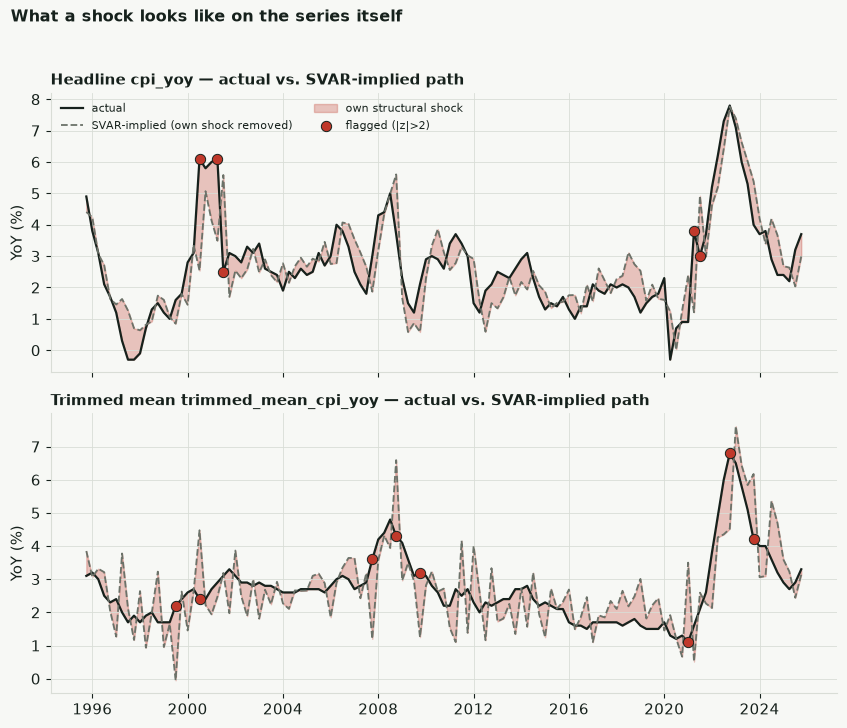

In [7]:
from src.models import svar
from src.models.tableau_export import SVAR_SYSTEMS

SHOCK_COLOR = "#c0392b"
IMPLIED_COLOR = "#6b7269"

panels = [("System A", "Headline"), ("System B", "Trimmed mean")]

fig, axes = plt.subplots(2, 1, figsize=(8.6, 7.4), sharex=True)
for ax, (system, label) in zip(axes, panels):
    config = SVAR_SYSTEMS[system]
    target = config["target"]
    frame = svar.load_svar_level_frame(columns=config["columns"])
    frame = frame.loc[frame.index <= svar.FORECAST_ORIGIN_PIN]
    fitted = svar.fit_svar(frame, ordering=config["ordering"])

    shocks = svar.structural_shocks(fitted)
    own = shocks[shocks["shock"] == target].copy()
    own["date"] = pd.PeriodIndex(own["quarter"], freq="Q").to_timestamp()
    own = own.sort_values("date")

    actual = frame.loc[pd.PeriodIndex(own["quarter"], freq="Q"), target].to_numpy()
    implied = actual - own["shock_value"].to_numpy()
    std = own["shock_value"].std()
    z = own["shock_value"] / std
    flagged = z.abs() > 2

    ax.plot(own["date"], actual, color=INK, linewidth=1.6, label="actual")
    ax.plot(own["date"], implied, color=IMPLIED_COLOR, linewidth=1.3, linestyle="--",
             label="SVAR-implied (own shock removed)")
    ax.fill_between(own["date"], actual, implied, color=SHOCK_COLOR, alpha=0.28,
                     label="own structural shock")
    ax.scatter(own.loc[flagged, "date"], actual[flagged.to_numpy()], s=55, color=SHOCK_COLOR,
               edgecolor=INK, linewidth=0.7, zorder=4, label="flagged (|z|>2)")
    ax.set_title(f"{label} {target} — actual vs. SVAR-implied path", loc="left",
                 fontsize=10.8, fontweight="bold")
    ax.set_ylabel("YoY (%)")

axes[0].legend(frameon=False, fontsize=8, ncol=2, loc="upper left")
fig.suptitle("What a shock looks like on the series itself", fontsize=11.5, fontweight="bold",
             x=0.02, ha="left")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()


#### The 2021 post-COVID reflation, decomposed

`historical_decomposition()` splits each system's actual path into a zero-shock baseline
plus cumulative contributions from the four macro drivers and the target's own shock — by
construction, baseline + Σ contributions reconstructs the actual path exactly (verified to
a maximum absolute error of ~1e-14 on this data).

Reading the chart quarter by quarter: through late 2020 and into early 2021, trimmed-mean
underlying inflation is still held down mostly by the lagged drag of pandemic-era
unemployment (`unemployment_rate` contributes roughly -1.1pp to -1.2pp across this
stretch); by **2021Q1** that drag combines with a further own-shock surprise (-0.77pp) to
produce the flagged downside miss. Two quarters later the picture flips: **2021Q2** brings
a sharp own-shock surge in headline inflation (+1.04pp) as rising commodity-price growth
(+0.65pp) and firming business inflation expectations (+0.26pp) increasingly outweigh the
now-fading unemployment drag (-0.94pp, down from -1.83pp two quarters earlier) — the same
pattern continues into **2021Q3** (own shock -0.37pp partly reversing 2021Q2's surge, but
commodity growth and expectations remain the dominant positive forces). Read together, it's
one connected story: pandemic-era slack was still suppressing underlying inflation as late
as early 2021, and within two quarters commodity-price and expectations effects had
reversed that entirely.

**Read this with the same caveat as the IRF panels above** — attributing a specific
quarter's move to a named driver rests on the same recursive Cholesky ordering, so it's a
*stronger* identification claim than a hypothetical IRF chart, not a weaker one.

*Source: `src/models/svar.py::historical_decomposition`, exported to
`reports/tableau/svar_historical_decomposition.csv`*

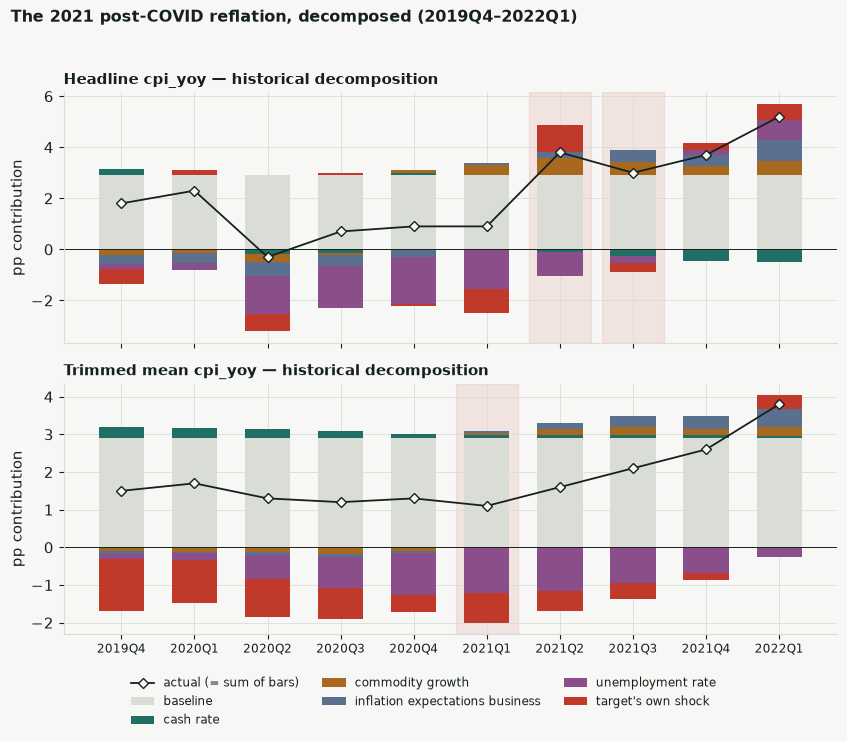

In [4]:
hd = pd.read_csv(PROJECT_ROOT / "reports/tableau/svar_historical_decomposition.csv")
window = hd[(hd["quarter"] >= "2019Q4") & (hd["quarter"] <= "2022Q1")].copy()

driver_colors = {
    "cash_rate": ACCENT,
    "commodity_growth": HIGHLIGHT,
    "inflation_expectations_business": "#5b6f8f",
    "unemployment_rate": "#8a4f8a",
}
OWN_SHOCK_COLOR = "#c0392b"
BASELINE_COLOR = GRID

panels = [
    ("System A", "cpi_yoy", "Headline cpi_yoy", ["2021Q2", "2021Q3"]),
    ("System B", "trimmed_mean_cpi_yoy", "Trimmed mean cpi_yoy", ["2021Q1"]),
]

fig, axes = plt.subplots(2, 1, figsize=(8.6, 7.2), sharex=True)
for ax, (system, target_col, label, flagged_quarters) in zip(axes, panels):
    sub = window[window["system"] == system]
    piv = sub.pivot_table(index="quarter", columns="component", values="contribution")
    piv = piv.reindex(sorted(piv.index, key=lambda q: pd.Period(q, freq="Q")))
    x = np.arange(len(piv))

    for fq in flagged_quarters:
        if fq in piv.index:
            xi = list(piv.index).index(fq)
            ax.axvspan(xi - 0.42, xi + 0.42, color=OWN_SHOCK_COLOR, alpha=0.10, zorder=0)

    order = ["baseline"] + list(driver_colors.keys()) + [target_col]
    bottom_pos = np.zeros(len(piv))
    bottom_neg = np.zeros(len(piv))
    for comp in order:
        vals = piv[comp].to_numpy()
        color = BASELINE_COLOR if comp == "baseline" else (
            OWN_SHOCK_COLOR if comp == target_col else driver_colors[comp]
        )
        comp_label = "target's own shock" if comp == target_col else comp.replace("_", " ")
        pos = np.where(vals > 0, vals, 0.0)
        neg = np.where(vals < 0, vals, 0.0)
        ax.bar(x, pos, bottom=bottom_pos, color=color, width=0.62, label=comp_label,
               zorder=2)
        ax.bar(x, neg, bottom=bottom_neg, color=color, width=0.62, zorder=2)
        bottom_pos += pos
        bottom_neg += neg

    actual = piv.sum(axis=1)
    ax.plot(x, actual, color=INK, marker="D", markersize=5, markerfacecolor=PAPER,
             markeredgecolor=INK, linewidth=1.3, label="actual (= sum of bars)", zorder=3)
    ax.axhline(0, color=INK, linewidth=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(piv.index, fontsize=8.5)
    ax.set_ylabel("pp contribution")
    ax.set_title(f"{label} — historical decomposition", loc="left", fontsize=10.5, fontweight="bold")

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc="lower center", ncol=3, fontsize=8.3, frameon=False,
           bbox_to_anchor=(0.5, -0.03))
fig.suptitle("The 2021 post-COVID reflation, decomposed (2019Q4–2022Q1)",
             fontsize=11.5, fontweight="bold", x=0.02, ha="left")
fig.tight_layout(rect=(0, 0.06, 1, 0.96))
plt.show()


#### A caveat: a record level isn't always a shock

Both series hit their all-time high in the *same* quarter — headline at 7.8%, trimmed mean
at 6.8%, both 2022Q4, both records since 1995. Only one of them is flagged as a shock.

The chart below shows why, computed live from the same two fitted systems used throughout
this section. Headline's raw single-equation residual that quarter was actually -0.057pp
(the plain VAR *slightly over-predicted*, at 7.857%) — but the Cholesky rotation
attributes most of that miss to commodity-growth's and unemployment's own same-quarter
shocks (which the ordering lets move CPI contemporaneously), leaving only +0.037pp
uniquely attributable to headline's own equation. Trimmed mean's structural shock that
same quarter is +2.28pp — genuinely large, and flagged.

**A record level and a shock are different questions, and this quarter shows they don't
always agree**: a sustained climb to an all-time high can be almost entirely priced in by
the model's own dynamics (headline's case), or it can still contain a genuine,
model-surprising jump on top of the climb (trimmed mean's case).

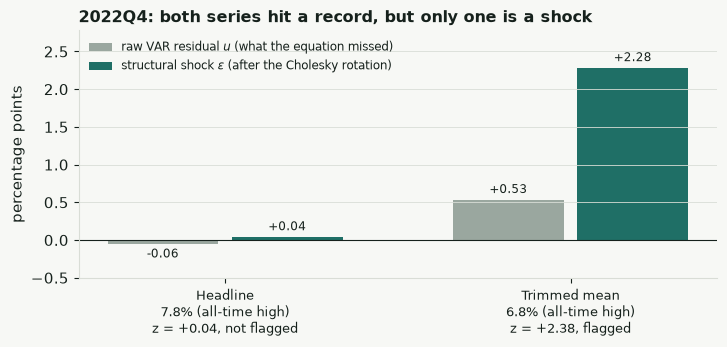

In [5]:
from src.models import svar
from src.models.tableau_export import SVAR_SYSTEMS

CAVEAT_QUARTER = pd.Period("2022Q4", freq="Q")

rows = []
for system, config in SVAR_SYSTEMS.items():
    target = config["target"]
    sys_frame = svar.load_svar_level_frame(columns=config["columns"])
    sys_frame = sys_frame.loc[sys_frame.index <= svar.FORECAST_ORIGIN_PIN]
    fitted = svar.fit_svar(sys_frame, ordering=config["ordering"])

    actual = sys_frame.loc[CAVEAT_QUARTER, target]
    u = fitted.resid.loc[CAVEAT_QUARTER, target]

    shocks = svar.structural_shocks(fitted)
    own = shocks[shocks["shock"] == target].set_index("quarter")
    eps = own.loc[str(CAVEAT_QUARTER), "shock_value"]
    std = own["shock_value"].std()

    rows.append({
        "system": "Headline" if system == "System A" else "Trimmed mean",
        "level": actual,
        "record": actual == sys_frame[target].max(),
        "u": u, "eps": eps, "z": eps / std, "flagged": bool(abs(eps / std) > 2),
    })
caveat = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.4, 3.6))
x = np.arange(len(caveat))
w = 0.32
b1 = ax.bar(x - w / 2 - 0.02, caveat["u"], w, color=MUTED, label="raw VAR residual $u$ (what the equation missed)")
b2 = ax.bar(x + w / 2 + 0.02, caveat["eps"], w, color=ACCENT, label=r"structural shock $\varepsilon$ (after the Cholesky rotation)")
ax.axhline(0, color=INK, linewidth=0.8)
for bars, col in ((b1, "u"), (b2, "eps")):
    for rect, v in zip(bars, caveat[col]):
        ax.annotate(f"{v:+.2f}", (rect.get_x() + rect.get_width() / 2, v), xytext=(0, 3 if v >= 0 else -3),
                    textcoords="offset points", ha="center", va="bottom" if v >= 0 else "top", fontsize=8.5)
labels = [f"{r.system}\n{r.level:.1f}% (all-time high)\nz = {r.z:+.2f}, " + ("flagged" if r.flagged else "not flagged")
          for r in caveat.itertuples()]
ax.set_xticks(x, labels, fontsize=9)
ax.set_ylim(min(caveat[["u", "eps"]].min().min() - 0.4, -0.5), caveat[["u", "eps"]].max().max() + 0.5)
ax.set_ylabel("percentage points")
ax.set_title("2022Q4: both series hit a record, but only one is a shock", loc="left", fontsize=11.5, fontweight="bold")
ax.legend(frameon=False, fontsize=8.3, loc="upper left")
ax.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()